# Agriculture Performance Analysis
## Python Data Analysis Project

Each analysis is kept in a **separate notebook cell/section** for clear presentation and viva.

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [5]:
# 2. Load Dataset
df = pd.read_csv("C:/Users/akash/Downloads/Telegram Desktop/seasonal_agriculture_performance_dataset.csv")
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [6]:
# 3. Dataset Information
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.dtypes.to_frame("Data Type"))

Rows: 4000
Columns: 28


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [7]:
# 4. Missing Values
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("Missing Values"))

,Missing Values
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [8]:
# 5. Descriptive Statistics
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


,Crop,Yield_Tonnes_Ha
6,Sugarcane,46.938746
3,Maize,2.717130
5,Rice,2.439413
7,Wheat,2.109216
0,Chilli,1.540344
2,Groundnut,1.317924
1,Cotton,1.225734
4,Pulses,0.918198


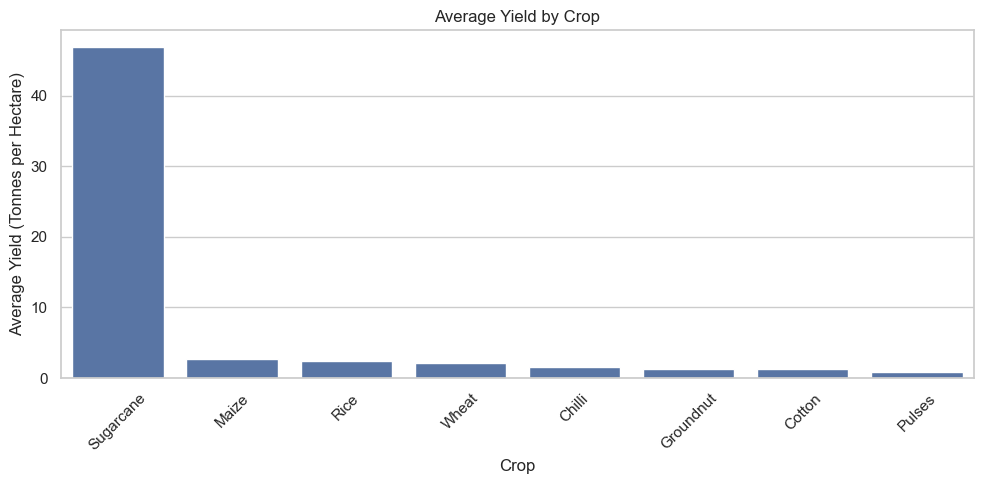

In [12]:
# 6. Crop-wise Yield Analysis

crop_yield = (
    df.groupby("Crop", as_index=False)["Yield_Tonnes_Ha"]
    .mean()
    .sort_values("Yield_Tonnes_Ha", ascending=False)
)

display(crop_yield)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=crop_yield,
    x="Crop",
    y="Yield_Tonnes_Ha"
)

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes per Hectare)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

,Season,Profit_INR
0,Kharif,178914.647555
1,Rabi,87689.470191
2,Zaid,-24804.824916


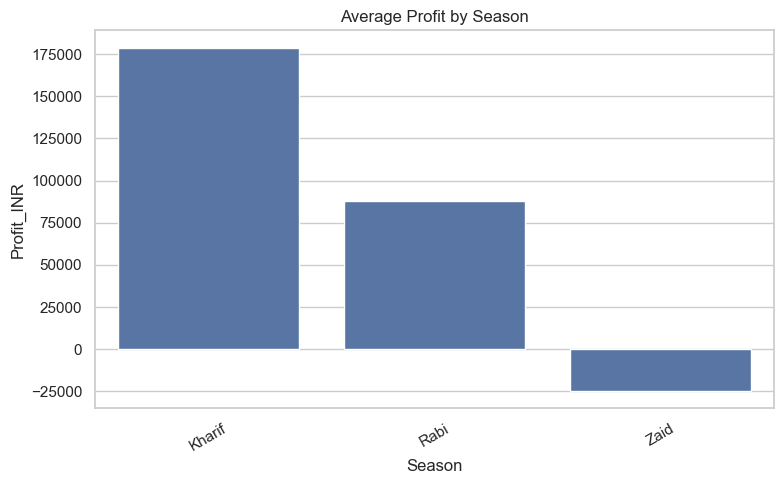

In [13]:
# 7. Season-wise Profit Analysis
season_profit = df.groupby("Season", as_index=False)["Profit_INR"].mean().sort_values("Profit_INR", ascending=False)
display(season_profit)
plt.figure(figsize=(8,5))
sns.barplot(data=season_profit, x="Season", y="Profit_INR")
plt.title("Average Profit by Season")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

,State,Profit_INR
5,Punjab,136025.636364
4,Maharashtra,135428.855469
2,Karnataka,119422.335378
6,Tamil Nadu,117744.748454
1,Gujarat,117568.235656
7,Telangana,108829.616279
3,Madhya Pradesh,86840.756539
0,Andhra Pradesh,73453.527410


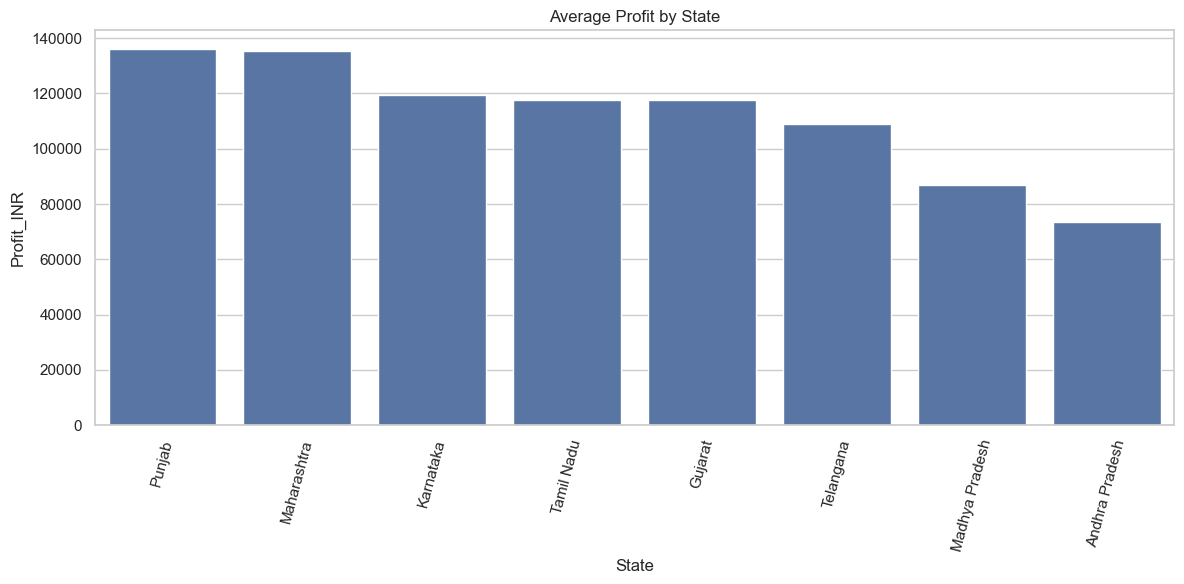

In [14]:
# 8. State-wise Profit Analysis
state_profit = df.groupby("State", as_index=False)["Profit_INR"].mean().sort_values("Profit_INR", ascending=False)
display(state_profit)
plt.figure(figsize=(12,6))
sns.barplot(data=state_profit, x="State", y="Profit_INR")
plt.title("Average Profit by State")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

,Irrigation_Method,Yield_Tonnes_Ha
0,Drip,6.620662
3,Sprinkler,5.188819
1,Flood,4.897724
2,Rainfed,4.613182


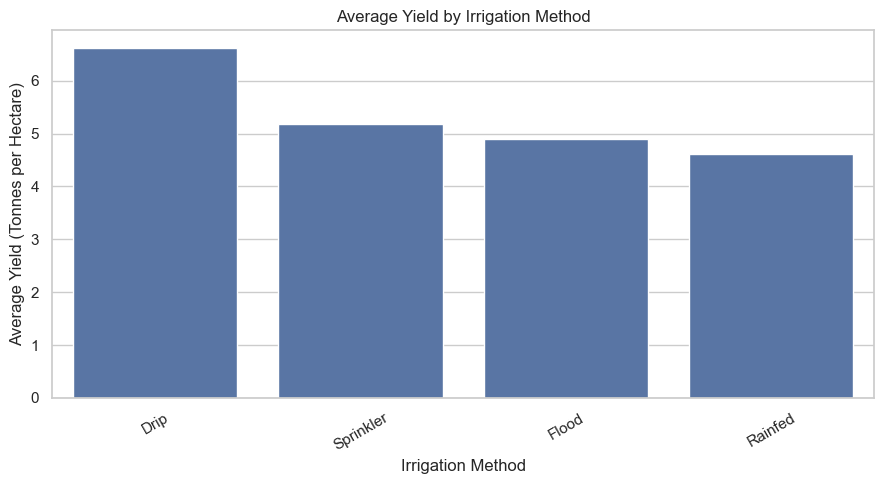

In [16]:
# 9. Irrigation-wise Yield Analysis

irrigation_yield = (
    df.groupby("Irrigation_Method", as_index=False)["Yield_Tonnes_Ha"]
    .mean()
    .sort_values("Yield_Tonnes_Ha", ascending=False)
)

display(irrigation_yield)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=irrigation_yield,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha"
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes per Hectare)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

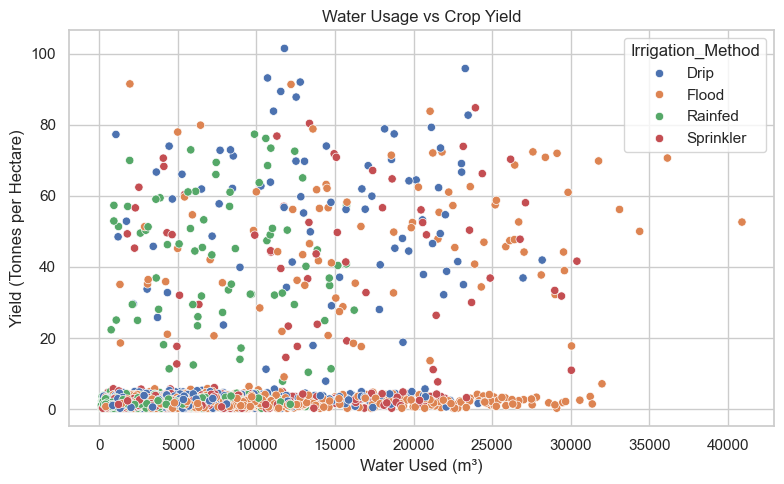

,Water_Used_m3,Yield_Tonnes_Ha
Water_Used_m3,1.000000,0.388653
Yield_Tonnes_Ha,0.388653,1.000000


In [18]:
# 10. Water Usage vs Yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha",
    hue="Irrigation_Method"
)

plt.title("Water Usage vs Crop Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes per Hectare)")

plt.tight_layout()
plt.show()

# Correlation between Water Usage and Yield
display(
    df[["Water_Used_m3", "Yield_Tonnes_Ha"]].corr()
)

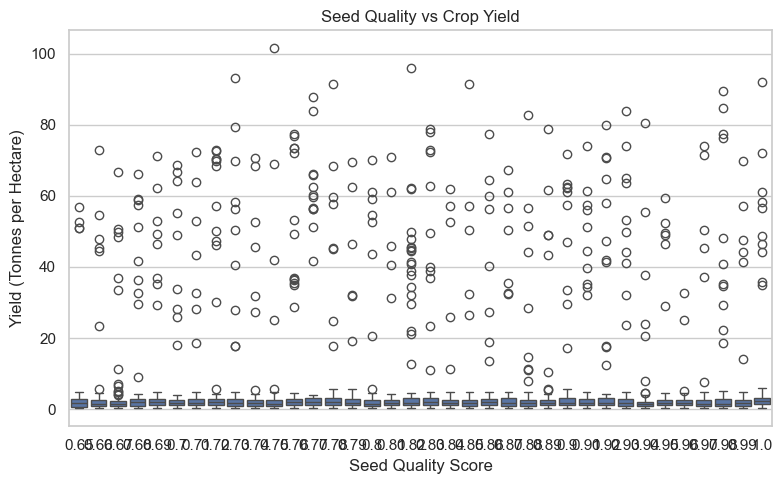

In [20]:
# 11. Seed Quality vs Yield

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Seed_Quality_Score",
    y="Yield_Tonnes_Ha"
)

plt.title("Seed Quality vs Crop Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes per Hectare)")

plt.tight_layout()
plt.show()

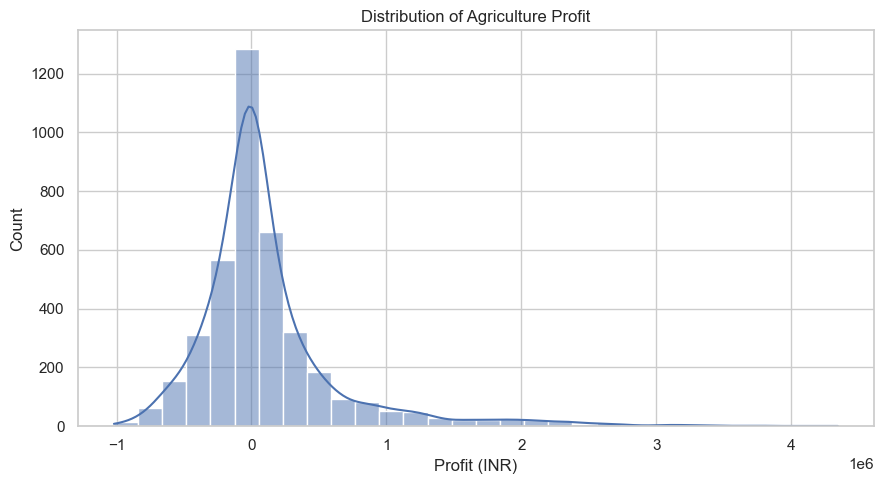

In [21]:
# 12. Profit Distribution
plt.figure(figsize=(9,5))
sns.histplot(df["Profit_INR"], bins=30, kde=True)
plt.title("Distribution of Agriculture Profit")
plt.xlabel("Profit (INR)")
plt.tight_layout()
plt.show()

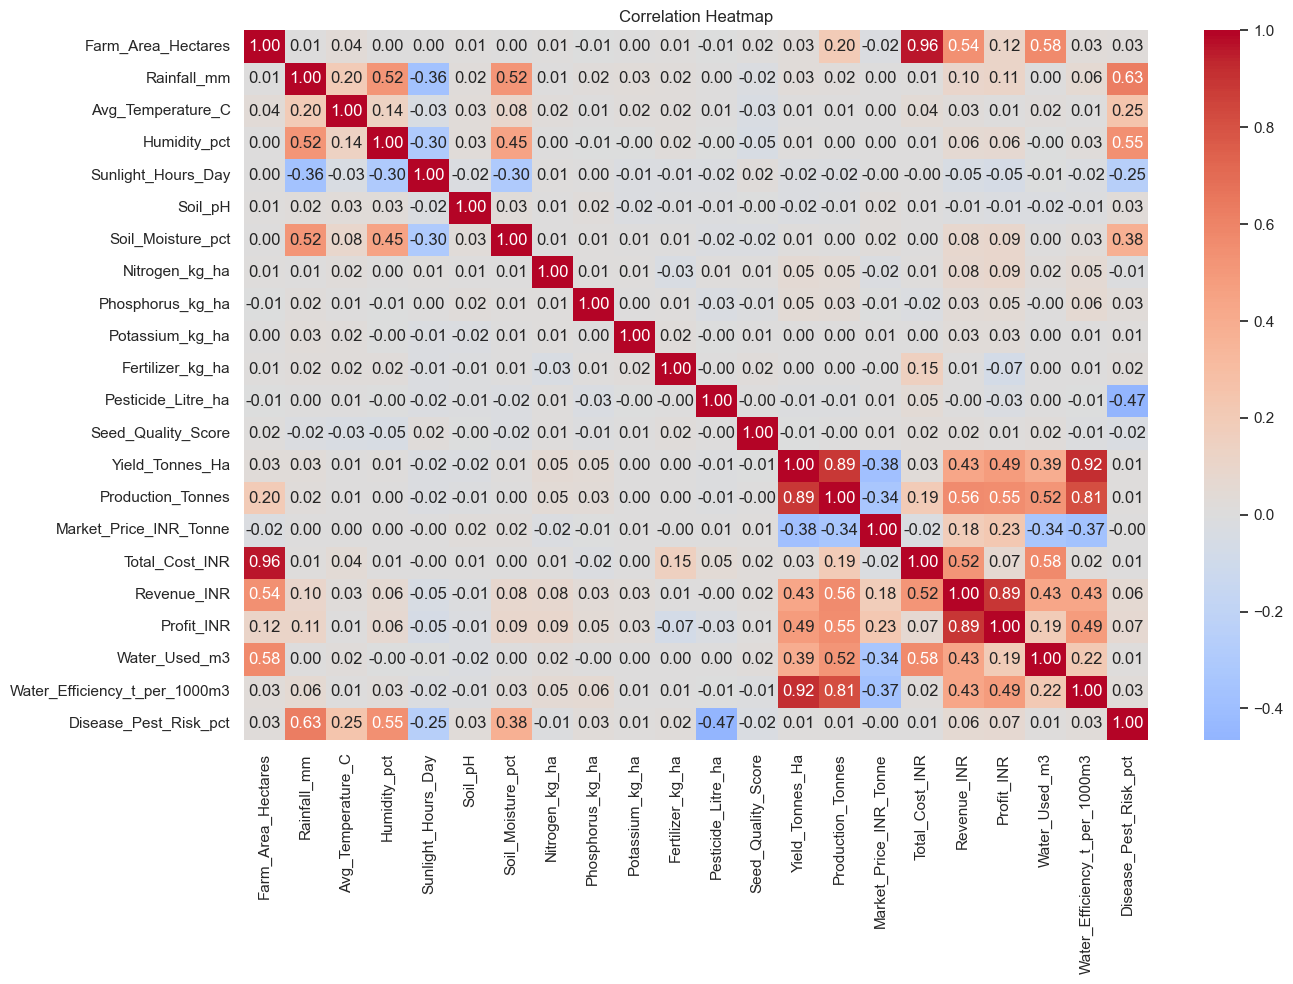

In [22]:
# 13. Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [26]:
# 14. Machine Learning - Yield Prediction

# Select required columns and remove rows where target is missing
df_ml = df.dropna(subset=["Yield_Tonnes_Ha"]).copy()

# Features and Target
X = df_ml.drop(columns=[
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR"
])

y = df_ml["Yield_Tonnes_Ha"]

# Convert categorical columns into numerical values
X = pd.get_dummies(X, drop_first=True)

# Handle missing values in features
X = X.fillna(0)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create Random Forest Model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))

MAE: 0.4673
RMSE: 1.5101
R² Score: 0.9852


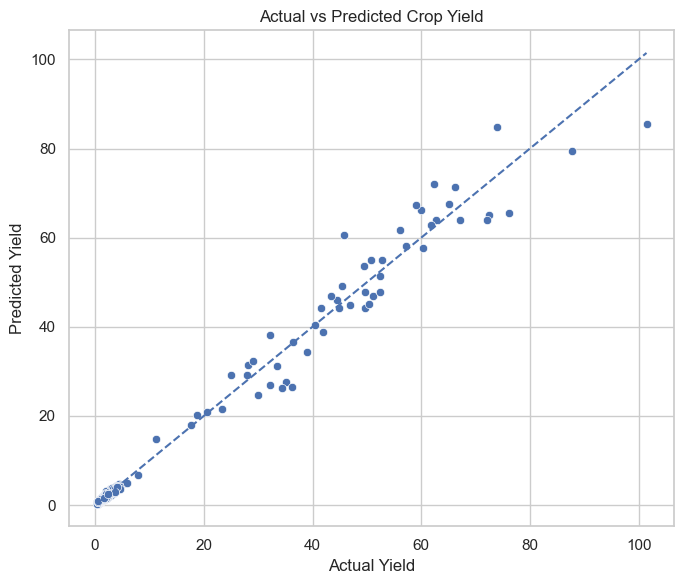

In [27]:
# 15. Actual vs Predicted Yield
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield")
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn,mx], [mn,mx], linestyle="--")
plt.tight_layout()
plt.show()

,Feature,Importance
16,Water_Efficiency_t_per_1000m3,0.941399
4011,Irrigation_Method_Rainfed,0.018449
13,Market_Price_INR_Tonne,0.011422
4010,Irrigation_Method_Flood,0.006866
4006,Crop_Sugarcane,0.003538
5,Soil_pH,0.003468
1,Rainfall_mm,0.001553
3,Humidity_pct,0.001319
15,Water_Used_m3,0.001221
8,Phosphorus_kg_ha,0.001210


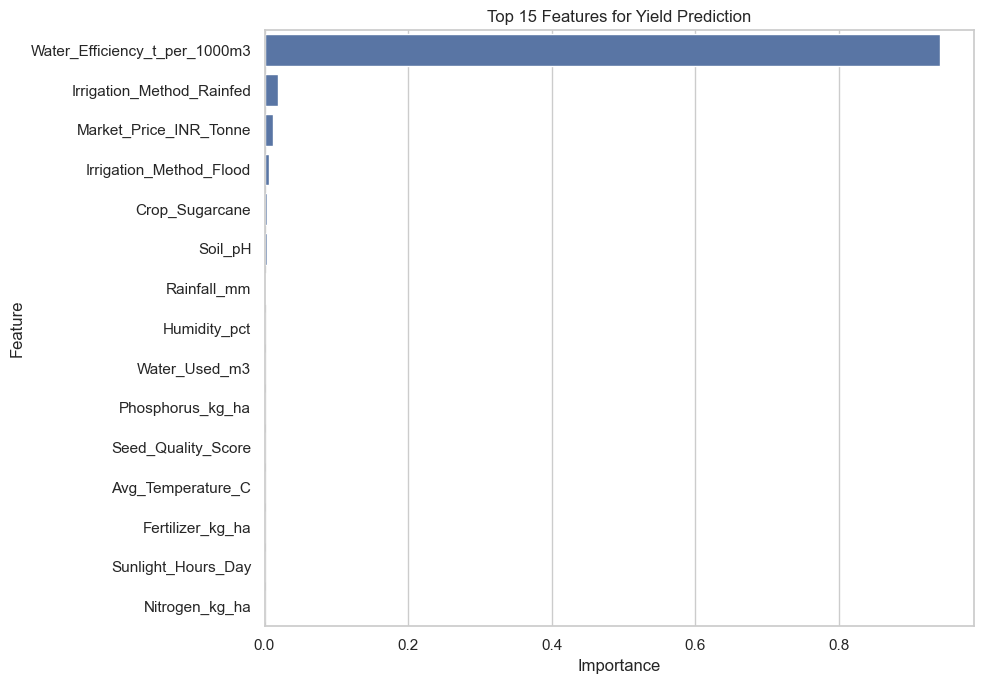

In [28]:
# 16. Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)
display(importance.head(15))

plt.figure(figsize=(10,7))
sns.barplot(data=importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Features for Yield Prediction")
plt.tight_layout()
plt.show()

## 17. Conclusion
The project analyzes agriculture performance through crop, season, state, irrigation, water usage, seed quality, profit and yield prediction. Each analysis is separated into its own code cell.